# Assignment_7_SVR_Regression

Implement SVM Algorithm for Regression.


## Aim
Implement Support Vector Regression (SVR) for a regression problem.

Result folder: /content/results


,Metric,Value
0,MAE,39.418658
1,MSE,2607.542290
2,R2,0.507839


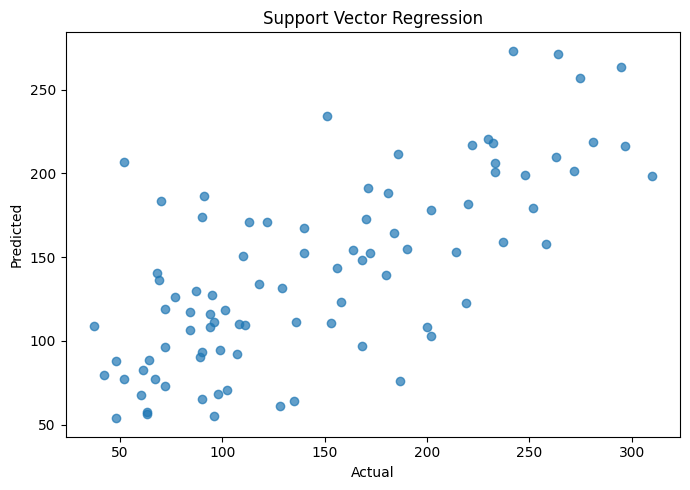

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = "/content/results"
os.makedirs(RESULT_DIR, exist_ok=True)

print("Result folder:", RESULT_DIR)

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

data=load_diabetes()
X_train,X_test,y_train,y_test=train_test_split(
    data.data,data.target,test_size=.2,random_state=42)

model=Pipeline([
    ("scaler",StandardScaler()),
    ("svr",SVR(kernel="rbf",C=100,gamma="scale",epsilon=.1))
])
model.fit(X_train,y_train)
pred=model.predict(X_test)

metrics=pd.DataFrame({
    "Metric":["MAE","MSE","R2"],
    "Value":[mean_absolute_error(y_test,pred),
             mean_squared_error(y_test,pred),
             r2_score(y_test,pred)]
})
display(metrics)
metrics.to_csv(f"{RESULT_DIR}/svr_metrics.csv",index=False)

plt.figure(figsize=(7,5))
plt.scatter(y_test,pred,alpha=.7)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Support Vector Regression")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/svr_plot.png",dpi=150)
plt.show()


In [ ]:
import shutil
from google.colab import files
shutil.make_archive("/content/Assignment_7_Results","zip",RESULT_DIR)
files.download("/content/Assignment_7_Results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>